# DISCO Treatment Effect Demo

This notebook shows how to load trained devices and compute treatment-effect outputs using `disco.notebook_utils`.

Run `python experiments/run_demo.py` first to generate demo assets (`experiments/demo_devices` and `experiments/results/demo_run`).


In [1]:
# Add parent directory to path
import sys
import os
sys.path.append(os.path.abspath('../..'))

In [2]:
from pathlib import Path
import numpy as np

from disco.notebook_utils import load_notebook_bundle, build_default_grids, compute_te_output
from disco.interventions.tabular import FeatureAdd, FeatureScale, ClampedShift


In [3]:
DEVICES_DIR = (Path('..').resolve() / 'demo_devices')
PROBES_DIR = (Path('..').resolve() / 'results' / 'demo_run' / 'probes')

bundle = load_notebook_bundle(DEVICES_DIR, PROBES_DIR)
print(f'Loaded {len(bundle.devices)} devices')
print(f'Probe pre-window theta0: {bundle.theta0}')
print(f'Probe set shape: {bundle.X_probe.shape}')
available = sorted({name for _, name in bundle.trajectories.keys()})
print(f'Available interventions: {available}')


Loaded 5 devices
Probe pre-window theta0: [0.  0.5 1. ]
Probe set shape: (200, 14)
Available interventions: ['add_f0', 'add_f1', 'clamped_f4', 'scale_f2', 'scale_f3']


In [4]:
target_device_index = 0  # pick which device to explain
query_idx = 0  # choose a probe sample as the private query

x_star = bundle.X_probe[query_idx]
print(f'Using device index {target_device_index} and probe #{query_idx}')


Using device index 0 and probe #0


In [5]:
INTERVENTIONS = {
    'add_f0': FeatureAdd(feat_idx=0, delta_max=3.0, name='add_f0'),
    'add_f1': FeatureAdd(feat_idx=1, delta_max=2.5, name='add_f1'),
    'scale_f2': FeatureScale(feat_idx=2, scale_max=0.5, name='scale_f2'),
    'scale_f3': FeatureScale(feat_idx=3, scale_max=0.8, name='scale_f3'),
    'clamped_f4': ClampedShift(feat_idx=4, shift_max=2.0, lower=-2.0, upper=2.0, name='clamped_f4'),
}

intervention_key = 'add_f0'
intervention = INTERVENTIONS[intervention_key]
print(f'Selected intervention: {intervention.name}')


Selected intervention: add_f0


In [6]:
grids = build_default_grids(bundle.theta0, n_post=8, gap=1.5)
te_output, result = compute_te_output(
    bundle,
    target_device_index=target_device_index,
    x_star=x_star,
    intervention=intervention,
    grids=grids,
    mode='p',
)

print(f'Signed TE AUC: {te_output.auc_signed:.4f}')
print(f'Abs TE AUC: {te_output.auc_abs:.4f}')
print(f'Peak intensity: {te_output.peak_theta:.4f}')
print(f'Peak treatment effect: {te_output.peak_tau:.4f}')


Signed TE AUC: 0.0765
Abs TE AUC: 0.0768
Peak intensity: 5.2500
Peak treatment effect: 0.0519


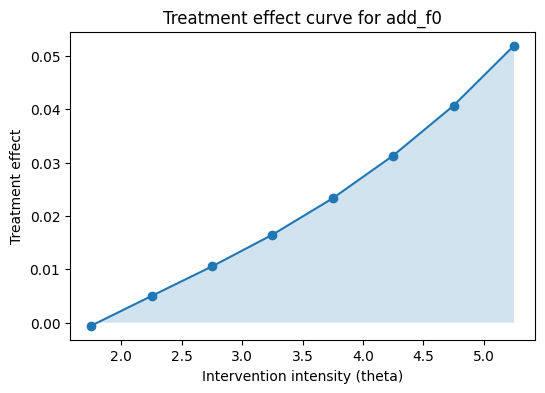

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(te_output.theta, te_output.tau, marker='o')
ax.fill_between(te_output.theta, te_output.tau, alpha=0.2)
ax.set_xlabel('Intervention intensity (theta)')
ax.set_ylabel('Treatment effect')
ax.set_title(f'Treatment effect curve for {intervention.name}')
plt.show()
